# EDA — Corpus de plaguicidas panameños (PubChem)

Análisis exploratorio de los datos descargados desde **PubChem** para el corpus panameño:

1. **Cobertura**: ingredientes activos MIDA vs familias químicas (HNID)
2. **Calidad**: SMILES válidos, duplicados, fórmulas moleculares
3. **Propiedades**: peso molecular, LogP, TPSA, átomos pesados
4. **Diversidad**: scaffolds de Murcko por familia
5. **Grupos funcionales**: patrones SMARTS de plaguicidas conocidos

**Requisito previo:** `make build-panama-corpus` (o al menos `data/raw/pubchem_panama_cids.csv`)

**Fuentes PubChem:**
- `Compound/name` → ingredientes activos del MIDA
- `Classification/hnid` → familias (organofosforados, triazinas, etc.)
- `Hazard/GHS` → etiquetas regulatorias (notebook `07_ghs_validation.ipynb`)

## 0. Configuración

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from rdkit import Chem
from rdkit.Chem import Descriptors, Lipinski, rdMolDescriptors
from rdkit.Chem.Scaffolds import MurckoScaffold

from src.data.pubchem_api import MIDA_ACTIVE_INGREDIENTS, FAMILY_HNIDS

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams.update({"figure.figsize": (12, 6), "figure.dpi": 120})

CIDS_CSV = ROOT / "data" / "raw" / "pubchem_panama_cids.csv"
GHS_CSV = ROOT / "data" / "raw" / "pubchem_ghs_labels.csv"
CORPUS_PT = ROOT / "data" / "processed" / "panama_corpus.pt"
FIG_DIR = ROOT / "outputs" / "panama" / "eda"
FIG_DIR.mkdir(parents=True, exist_ok=True)

print(f"Raíz: {ROOT}")
print(f"Figuras: {FIG_DIR}")

Raíz: c:\Users\mateo\Desktop\PROYECTOS\JIC2026
Figuras: c:\Users\mateo\Desktop\PROYECTOS\JIC2026\outputs\panama\eda


## 1. Carga del corpus CSV

In [2]:
if not CIDS_CSV.is_file():
    raise FileNotFoundError(
        f"No existe {CIDS_CSV}. Ejecuta: make build-panama-corpus"
    )

df = pd.read_csv(CIDS_CSV)
smiles_col = "SMILES_canonical" if "SMILES_canonical" in df.columns else "SMILES"

print(f"Filas en CSV: {len(df)}")
print(f"Columnas: {list(df.columns)}")
print(f"CIDs únicos: {df['CID'].nunique()}")
display(df.head(8))

Filas en CSV: 235
Columnas: ['name', 'CID', 'SMILES', 'formula', 'source', 'family', 'SMILES_canonical']
CIDs únicos: 235


,name,CID,SMILES,formula,source,family,SMILES_canonical
0,Chlorpyrifos,2730,CCOP(=S)(OCC)OC1=NC(=C(C=C1Cl)Cl)Cl,C9H11Cl3NO3PS,MIDA_name_search,mixed,CCOP(=S)(OCC)Oc1nc(Cl)c(Cl)cc1Cl
1,Malathion,4004,CCOC(=O)CC(C(=O)OCC)SP(=S)(OC)OC,C10H19O6PS2,MIDA_name_search,mixed,CCOC(=O)CC(SP(=S)(OC)OC)C(=O)OCC
2,Dimethoate,3082,CNC(=O)CSP(=S)(OC)OC,C5H12NO3PS2,MIDA_name_search,mixed,CNC(=O)CSP(=S)(OC)OC
3,Methyl parathion,4130,COP(=S)(OC)OC1=CC=C(C=C1)[N+](=O)[O-],C8H10NO5PS,MIDA_name_search,mixed,COP(=S)(OC)Oc1ccc([N+](=O)[O-])cc1
4,Carbaryl,6129,CNC(=O)OC1=CC=CC2=CC=CC=C21,C12H11NO2,MIDA_name_search,mixed,CNC(=O)Oc1cccc2ccccc12
5,Methomyl,4109,CC(=NOC(=O)NC)SC,C5H10N2O2S,MIDA_name_search,mixed,CNC(=O)ON=C(C)SC
6,Aldicarb,9570071,CC(C)(/C=N/OC(=O)NC)SC,C7H14N2O2S,MIDA_name_search,mixed,CNC(=O)O/N=C/C(C)(C)SC
7,Atrazine,2256,CCNC1=NC(=NC(=N1)Cl)NC(C)C,C8H14ClN5,MIDA_name_search,mixed,CCNc1nc(Cl)nc(NC(C)C)n1


## 2. Panorama por fuente y familia

,métrica,valor
0,Total compuestos,235
1,Ingredientes MIDA (por nombre),20
2,Por clasificación PubChem,215
3,Familias distintas,7


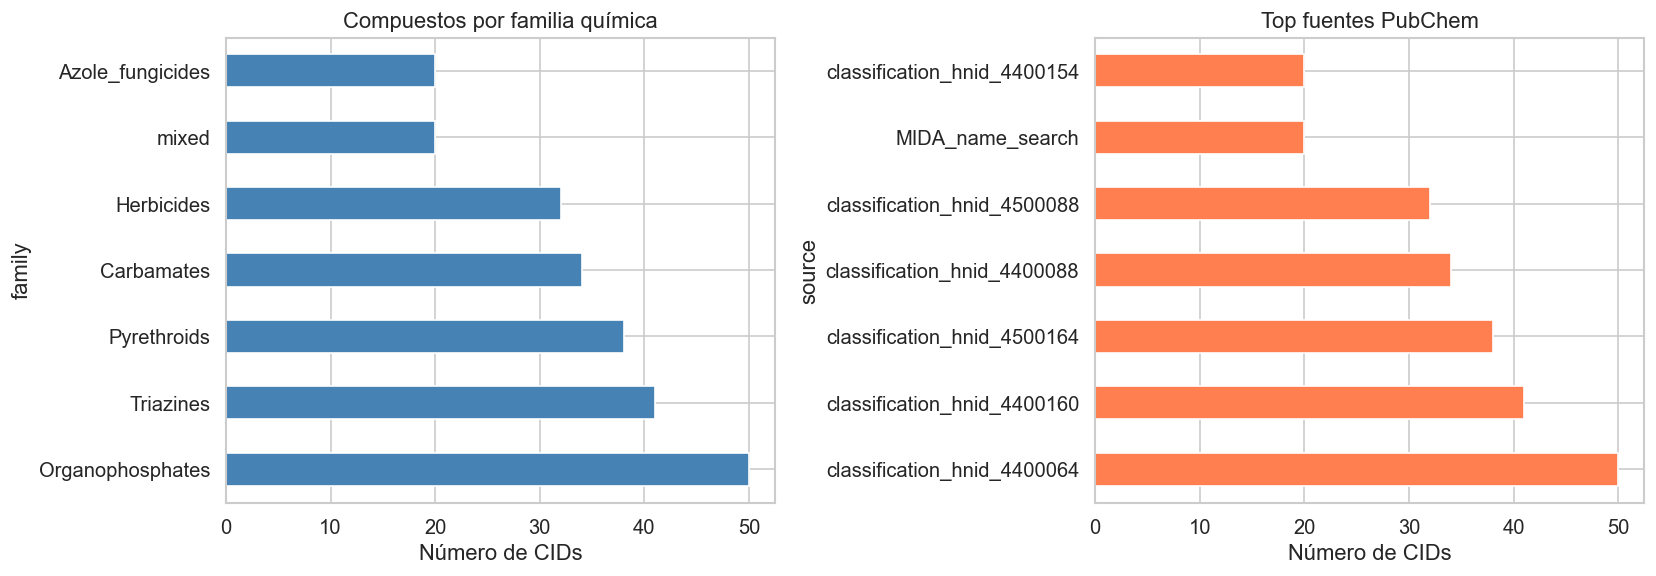

HNIDs configurados en pubchem_api.py:
  Organophosphates     hnid=4400064 → 50 CIDs en CSV
  Carbamates           hnid=4400088 → 34 CIDs en CSV
  Triazines            hnid=4400160 → 41 CIDs en CSV
  Azole_fungicides     hnid=4400154 → 20 CIDs en CSV
  Pyrethroids          hnid=4500164 → 38 CIDs en CSV
  Herbicides           hnid=4500088 → 32 CIDs en CSV


In [3]:
mida_mask = df["source"] == "MIDA_name_search"
class_mask = df["source"].str.startswith("classification_hnid", na=False)

summary = pd.DataFrame({
    "métrica": [
        "Total compuestos",
        "Ingredientes MIDA (por nombre)",
        "Por clasificación PubChem",
        "Familias distintas",
    ],
    "valor": [
        len(df),
        int(mida_mask.sum()),
        int(class_mask.sum()),
        df["family"].nunique(),
    ],
})
display(summary)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

fam_counts = df["family"].value_counts()
fam_counts.plot(kind="barh", ax=axes[0], color="steelblue")
axes[0].set_title("Compuestos por familia química")
axes[0].set_xlabel("Número de CIDs")

src_counts = df["source"].value_counts().head(10)
src_counts.plot(kind="barh", ax=axes[1], color="coral")
axes[1].set_title("Top fuentes PubChem")
axes[1].set_xlabel("Número de CIDs")

plt.tight_layout()
fig.savefig(FIG_DIR / "corpus_by_family_source.png", bbox_inches="tight")
plt.show()

print("HNIDs configurados en pubchem_api.py:")
for fam, hnid in FAMILY_HNIDS.items():
    n = int((df["source"] == f"classification_hnid_{hnid}").sum())
    print(f"  {fam:20s} hnid={hnid:7d} → {n} CIDs en CSV")

## 3. Cobertura de ingredientes activos MIDA

In [4]:
mida_df = df.loc[mida_mask].copy()
found = set(mida_df["name"].str.strip())
expected = set(MIDA_ACTIVE_INGREDIENTS)
missing = sorted(expected - found)
extra = sorted(found - expected)

print(f"Esperados (MIDA): {len(expected)}")
print(f"Encontrados en CSV: {len(found)}")
if missing:
    print(f"\nFaltantes ({len(missing)}): {missing}")
else:
    print("\n✓ Todos los ingredientes MIDA están en el corpus.")
if extra:
    print(f"Extra (no en lista MIDA): {extra}")

display(mida_df[["name", "CID", "formula", smiles_col]].sort_values("name"))

Esperados (MIDA): 20
Encontrados en CSV: 20

✓ Todos los ingredientes MIDA están en el corpus.


,name,CID,formula,SMILES_canonical
17,"2,4-D",1486,C8H6Cl2O3,O=C(O)COc1ccc(Cl)cc1Cl
6,Aldicarb,9570071,C7H14N2O2S,CNC(=O)O/N=C/C(C)(C)SC
7,Atrazine,2256,C8H14ClN5,CCNc1nc(Cl)nc(NC(C)C)n1
4,Carbaryl,6129,C12H11NO2,CNC(=O)Oc1cccc2ccccc12
19,Chlorothalonil,15910,C8Cl4N2,N#Cc1c(Cl)c(Cl)c(Cl)c(C#N)c1Cl
0,Chlorpyrifos,2730,C9H11Cl3NO3PS,CCOP(=S)(OCC)Oc1nc(Cl)c(Cl)cc1Cl
12,Cypermethrin,2912,C22H19Cl2NO3,CC1(C)C(C=C(Cl)Cl)C1C(=O)OC(C#N)c1cccc(Oc2cccc...
13,Deltamethrin,40585,C22H19Br2NO3,CC1(C)[C@H](C(=O)O[C@H](C#N)c2cccc(Oc3ccccc3)c...
11,Difenoconazole,86173,C19H17Cl2N3O3,CC1COC(Cn2cncn2)(c2ccc(Oc3ccc(Cl)cc3)cc2Cl)O1
2,Dimethoate,3082,C5H12NO3PS2,CNC(=O)CSP(=S)(OC)OC


## 4. Propiedades moleculares (RDKit)

Moléculas con propiedades calculadas: 235 / 235


[22:31:55] WARNING: not removing hydrogen atom without neighbors


,MW,LogP,TPSA,HBD,HBA,HeavyAtoms,RotBonds,Rings,CID
count,235.00,235.00,235.00,235.00,235.00,235.00,235.00,235.00,235.00
mean,169.56,0.18,69.15,2.01,3.04,10.90,2.49,0.71,83135.74
std,111.89,1.95,49.34,1.78,2.45,6.98,2.40,1.00,775339.96
min,2.02,-5.40,0.00,0.00,0.00,0.00,0.00,0.00,3.00
25%,100.08,-1.01,37.30,1.00,2.00,6.50,0.00,0.00,206.50
50%,146.14,-0.06,62.73,2.00,3.00,10.00,2.00,0.00,499.00
75%,216.89,1.10,91.16,3.00,4.00,13.00,4.00,1.00,1026.50
max,767.54,6.54,346.56,10.00,17.00,48.00,18.00,5.00,9570071.00


C:\Users\mateo\AppData\Local\Temp\ipykernel_42180\1568419904.py:38: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
C:\Users\mateo\AppData\Local\Temp\ipykernel_42180\1568419904.py:38: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
C:\Users\mateo\AppData\Local\Temp\ipykernel_42180\1568419904.py:38: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
C:\Users\mateo\AppData\Local\Temp\ipykernel_42180\1568419904.py:38: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xti

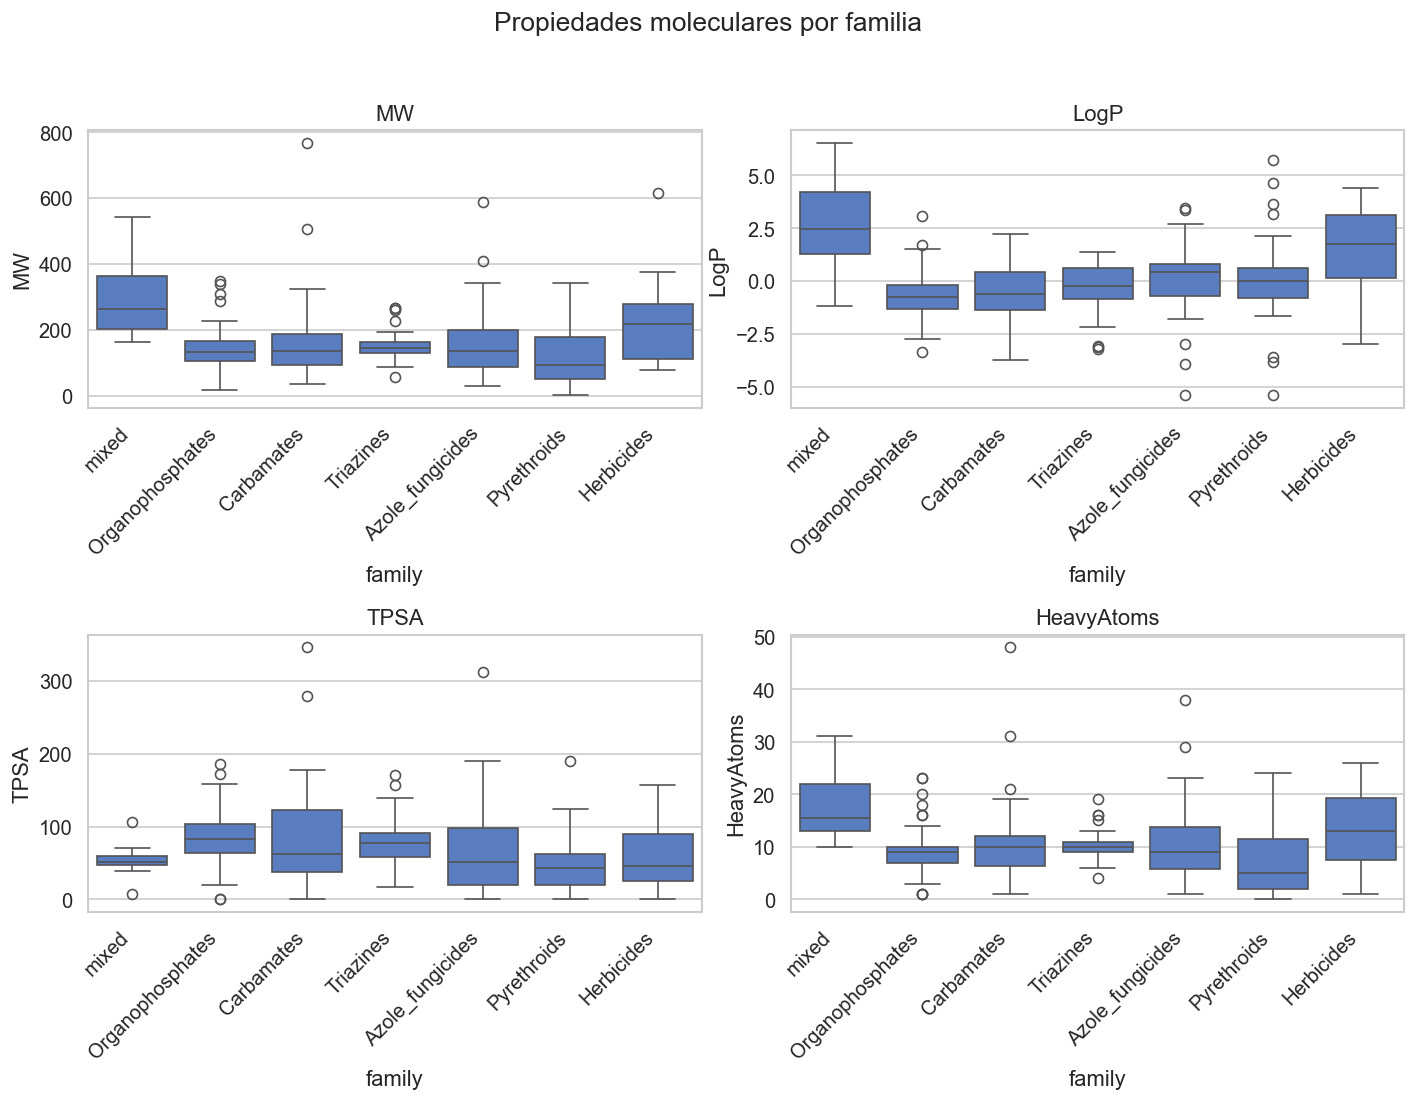

In [5]:
def mol_props(smiles: str) -> dict | None:
    if not isinstance(smiles, str) or not smiles.strip():
        return None
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    return {
        "MW": Descriptors.MolWt(mol),
        "LogP": Descriptors.MolLogP(mol),
        "TPSA": Descriptors.TPSA(mol),
        "HBD": Lipinski.NumHDonors(mol),
        "HBA": Lipinski.NumHAcceptors(mol),
        "HeavyAtoms": Lipinski.HeavyAtomCount(mol),
        "RotBonds": Lipinski.NumRotatableBonds(mol),
        "Rings": rdMolDescriptors.CalcNumRings(mol),
    }


props_list = []
for _, row in df.iterrows():
    smi = row.get(smiles_col, "")
    p = mol_props(smi)
    if p is None:
        continue
    p["CID"] = row["CID"]
    p["name"] = row.get("name", "")
    p["family"] = row.get("family", "")
    p["is_mida"] = row["source"] == "MIDA_name_search"
    props_list.append(p)

props_df = pd.DataFrame(props_list)
print(f"Moléculas con propiedades calculadas: {len(props_df)} / {len(df)}")
display(props_df.describe().round(2))

fig, axes = plt.subplots(2, 2, figsize=(12, 9))
for ax, col in zip(axes.ravel(), ["MW", "LogP", "TPSA", "HeavyAtoms"]):
    sns.boxplot(data=props_df, x="family", y=col, ax=ax)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
    ax.set_title(col)
plt.suptitle("Propiedades moleculares por familia", y=1.02)
plt.tight_layout()
fig.savefig(FIG_DIR / "molecular_properties_by_family.png", bbox_inches="tight")
plt.show()

## 5. Scaffolds de Murcko (diversidad estructural)

In [6]:
def murcko_scaffold(smiles: str) -> str | None:
    mol = Chem.MolFromSmiles(smiles) if isinstance(smiles, str) else None
    if mol is None:
        return None
    return MurckoScaffold.MurckoScaffoldSmiles(mol=mol, includeChirality=False)


df_scaf = df.copy()
df_scaf["scaffold"] = df_scaf[smiles_col].apply(murcko_scaffold)
valid_scaf = df_scaf.dropna(subset=["scaffold"])

scaf_by_family = (
    valid_scaf.groupby("family")["scaffold"].nunique()
    .sort_values(ascending=False)
    .rename("scaffolds_únicos")
)
count_by_family = valid_scaf["family"].value_counts().rename("compuestos")
diversity = pd.concat([count_by_family, scaf_by_family], axis=1)
diversity["ratio_scaffold/compuesto"] = (
    diversity["scaffolds_únicos"] / diversity["compuestos"]
).round(2)
display(diversity)

mida_scaf = valid_scaf.loc[mida_mask, ["name", "scaffold"]].drop_duplicates()
print(f"\nScaffolds únicos (ingredientes MIDA): {mida_scaf['scaffold'].nunique()} / {len(mida_scaf)}")
display(mida_scaf.head(12))

[22:31:57] WARNING: not removing hydrogen atom without neighbors


,compuestos,scaffolds_únicos,ratio_scaffold/compuesto
family,,,
Organophosphates,50,14,0.28
Triazines,41,9,0.22
Pyrethroids,38,9,0.24
Carbamates,34,8,0.24
Herbicides,32,16,0.50
mixed,20,10,0.50
Azole_fungicides,20,7,0.35



Scaffolds únicos (ingredientes MIDA): 10 / 20


,name,scaffold
0,Chlorpyrifos,c1ccncc1
1,Malathion,
2,Dimethoate,
3,Methyl parathion,c1ccccc1
4,Carbaryl,c1ccc2ccccc2c1
5,Methomyl,
6,Aldicarb,
7,Atrazine,c1ncncn1
8,Simazine,c1ncncn1
9,Tebuconazole,c1ccc(CCCCn2cncn2)cc1


## 6. Grupos funcionales tóxicos (SMARTS)

[22:31:57] WARNING: not removing hydrogen atom without neighbors
[22:31:58] WARNING: not removing hydrogen atom without neighbors
[22:31:58] WARNING: not removing hydrogen atom without neighbors
[22:31:58] WARNING: not removing hydrogen atom without neighbors
[22:31:58] WARNING: not removing hydrogen atom without neighbors
[22:31:58] WARNING: not removing hydrogen atom without neighbors
[22:31:58] WARNING: not removing hydrogen atom without neighbors
[22:31:58] WARNING: not removing hydrogen atom without neighbors


,grupo_funcional,n_total,n_mida
6,Fosfonato,24,1
4,Piretroide (éster),7,4
2,Carbamato,6,3
0,Organofosforado (P=S),5,4
7,Nitroaromático,5,1
3,Azol (triazol),4,3
1,Triazina,2,2
5,Bipiridilio (paraquat),1,1


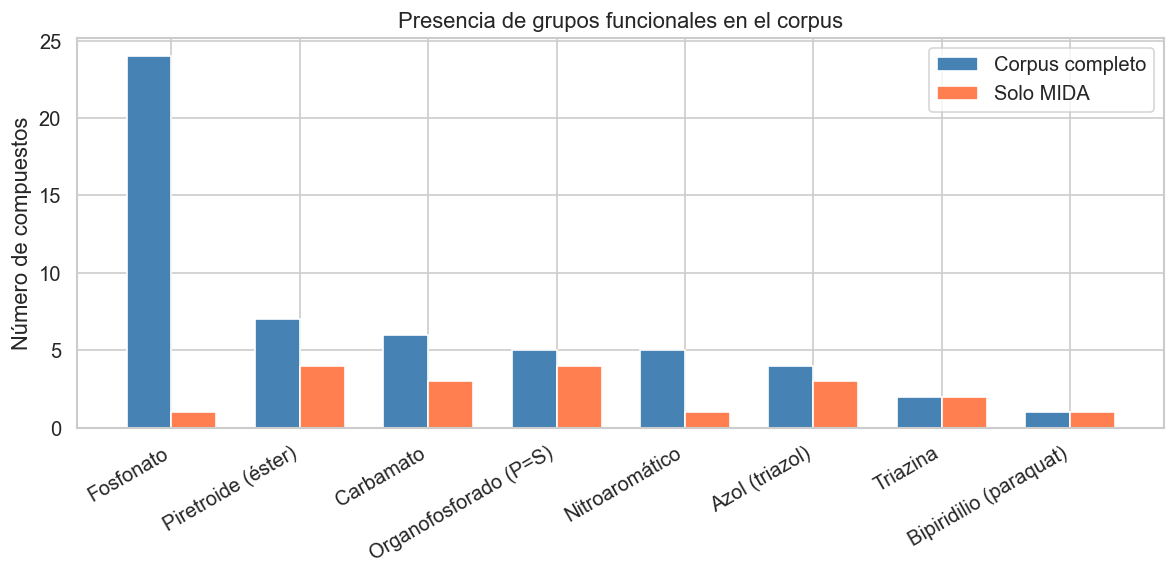

In [7]:
FUNCTIONAL_GROUPS = {
    "Organofosforado (P=S)": "[P](=S)([O,S])([O,S])",
    "Triazina": "c1ncncn1",
    "Carbamato": "NC(=O)O",
    "Azol (triazol)": "n1cncn1",
    "Piretroide (éster)": "C(=O)OC",
    "Bipiridilio (paraquat)": "[n+]1ccc(-c2cc[n+](C)cc2)cc1",
    "Fosfonato": "P(=O)(O)",
    "Nitroaromático": "[N+](=O)[O-]",
}

def has_smarts(smiles: str, smarts: str) -> bool:
    mol = Chem.MolFromSmiles(smiles) if isinstance(smiles, str) else None
    query = Chem.MolFromSmarts(smarts)
    if mol is None or query is None:
        return False
    return mol.HasSubstructMatch(query)


fg_rows = []
for label, smarts in FUNCTIONAL_GROUPS.items():
    hits = df[smiles_col].apply(lambda s: has_smarts(s, smarts))
    fg_rows.append({
        "grupo_funcional": label,
        "n_total": int(hits.sum()),
        "n_mida": int(hits[mida_mask].sum()),
    })

fg_df = pd.DataFrame(fg_rows).sort_values("n_total", ascending=False)
display(fg_df)

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(fg_df))
w = 0.35
ax.bar(x - w/2, fg_df["n_total"], w, label="Corpus completo", color="steelblue")
ax.bar(x + w/2, fg_df["n_mida"], w, label="Solo MIDA", color="coral")
ax.set_xticks(x)
ax.set_xticklabels(fg_df["grupo_funcional"], rotation=30, ha="right")
ax.set_ylabel("Número de compuestos")
ax.set_title("Presencia de grupos funcionales en el corpus")
ax.legend()
plt.tight_layout()
fig.savefig(FIG_DIR / "functional_groups.png", bbox_inches="tight")
plt.show()

## 7. Calidad de datos y corpus PyG

In [8]:
invalid_smiles = df[smiles_col].isna() | (df[smiles_col].astype(str).str.strip() == "")
dup_cids = df["CID"].duplicated(keep=False)

quality = pd.DataFrame({
    "check": ["SMILES vacíos", "CIDs duplicados", "Sin fórmula (MIDA)", "Con fórmula (MIDA)"],
    "n": [
        int(invalid_smiles.sum()),
        int(dup_cids.sum()),
        int(mida_df["formula"].fillna("").eq("").sum()),
        int(mida_df["formula"].fillna("").ne("").sum()),
    ],
})
display(quality)

if CORPUS_PT.is_file():
    import torch
    try:
        corpus = torch.load(CORPUS_PT, map_location="cpu", weights_only=False)
    except TypeError:
        corpus = torch.load(CORPUS_PT, map_location="cpu")
    meta = corpus.get("meta", {})
    print(f"\npanama_corpus.pt: {meta.get('n_graphs', '?')} grafos PyG")
    print(f"  Filas CSV: {meta.get('n_csv_rows', '?')}")
    print(f"  Fallidos:  {meta.get('n_failed', '?')}")
else:
    print(f"\n[AVISO] No existe {CORPUS_PT}. Ejecuta make build-panama-corpus para grafos PyG.")

if GHS_CSV.is_file():
    ghs = pd.read_csv(GHS_CSV)
    with_codes = ghs["ghs_codes"].fillna("").ne("").sum()
    print(f"\nEtiquetas GHS: {len(ghs)} CIDs | con códigos H: {with_codes}")
    print("  → Análisis detallado en notebooks/07_ghs_validation.ipynb")
else:
    print("\n[AVISO] No hay pubchem_ghs_labels.csv (usa make build-panama-corpus sin --skip-ghs)")

print(f"\nFiguras guardadas en: {FIG_DIR}")

,check,n
0,SMILES vacíos,0
1,CIDs duplicados,0
2,Sin fórmula (MIDA),0
3,Con fórmula (MIDA),20


c:\Users\mateo\Desktop\PROYECTOS\JIC2026\.venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm



panama_corpus.pt: 235 grafos PyG
  Filas CSV: 235
  Fallidos:  0

Etiquetas GHS: 235 CIDs | con códigos H: 0
  → Análisis detallado en notebooks/07_ghs_validation.ipynb

Figuras guardadas en: c:\Users\mateo\Desktop\PROYECTOS\JIC2026\outputs\panama\eda
